<a href="https://colab.research.google.com/github/yashmahajan11234567/PRIMETradeAI/blob/main/Trader_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Part B** — Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,6)

In [3]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv('Trader_analysis.csv')

df.head()

Saving Trader_analysis.csv to Trader_analysis.csv


,Trade_Date,classification,Account,Daily_PnL,Avg_Trade_Size,Trades_Per_Day,Win_Rate,Long_Trades,Short_Trades,Trading_Bias,Long_Short_Ratio_Fixed
0,28-03-2023,Greed,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,159.000000,3,0.000000,3,0,Only_Long,0.000000
1,14-11-2023,Greed,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,23066.935000,2,0.000000,2,0,Only_Long,0.000000
2,14-11-2023,Greed,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,11034.799510,1043,27.516779,489,554,Short_Biased,0.882671
3,09-03-2024,Extreme Greed,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,3048.594444,27,33.333333,4,23,Short_Biased,0.173913
4,09-03-2024,Extreme Greed,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,1136.312727,88,0.000000,88,0,Only_Long,0.000000


In [5]:
print(df.shape)
print(df.columns.tolist())

(77, 11)
['Trade_Date', 'classification', 'Account', 'Daily_PnL', 'Avg_Trade_Size', 'Trades_Per_Day', 'Win_Rate', 'Long_Trades', 'Short_Trades', 'Trading_Bias', 'Long_Short_Ratio_Fixed']


#**Question 1**
##Does performance differ between Fear vs Greed days?

###Average Daily PnL by Sentiment

In [6]:
pnl_analysis = (
    df.groupby('classification')['Daily_PnL']
      .agg(['mean', 'median', 'sum', 'count'])
      .round(2)
)

print(pnl_analysis)

                     mean    median         sum  count
classification                                        
Extreme Greed    35393.10      0.00   176965.49      5
Fear            209372.66  81389.68  6699925.19     32
Greed            99675.52  35988.38  3189616.54     32
Neutral          19842.80     -0.42   158742.38      8


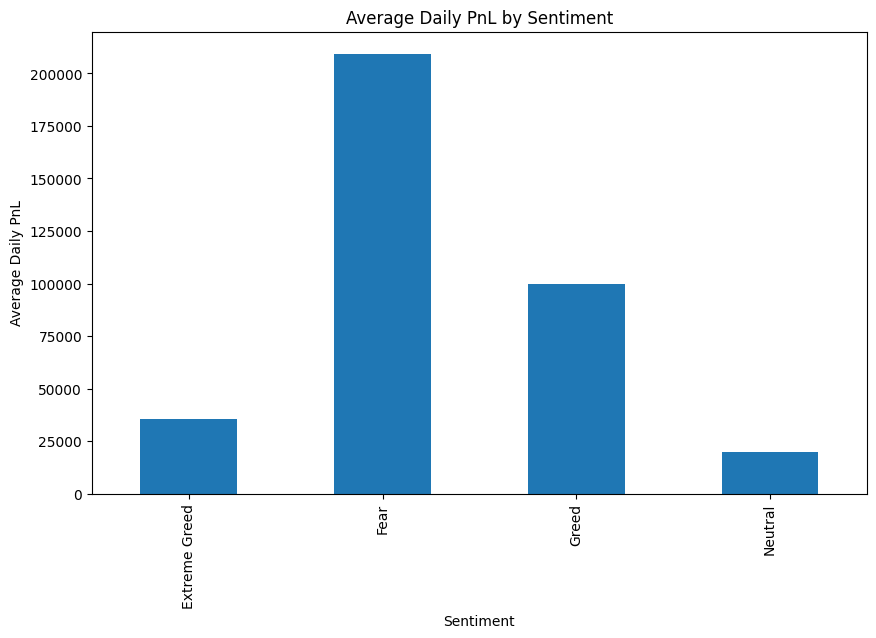

In [7]:
import matplotlib.pyplot as plt

pnl_analysis['mean'].plot(kind='bar')

plt.title('Average Daily PnL by Sentiment')
plt.ylabel('Average Daily PnL')
plt.xlabel('Sentiment')
plt.show()

###Average Win Rate by Sentiment

In [8]:
win_rate_analysis = (
    df.groupby('classification')['Win_Rate']
      .mean()
      .round(2)
)

print(win_rate_analysis)

classification
Extreme Greed    33.66
Fear             41.59
Greed            37.41
Neutral          26.07
Name: Win_Rate, dtype: float64


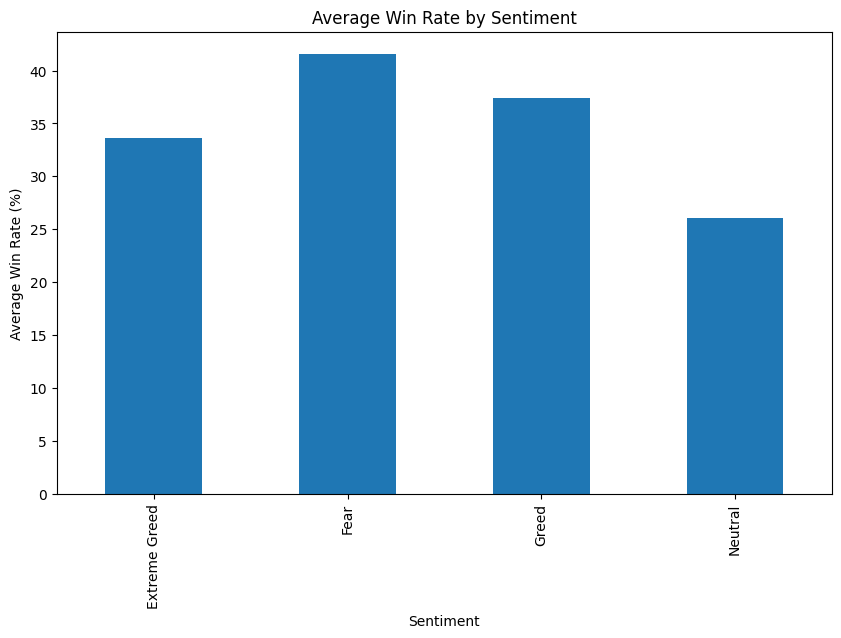

In [9]:
win_rate_analysis.plot(kind='bar')

plt.title('Average Win Rate by Sentiment')
plt.ylabel('Average Win Rate (%)')
plt.xlabel('Sentiment')
plt.show()

###Drawdown Proxy

In [10]:
loss_df = df[df['Daily_PnL'] < 0]

drawdown_analysis = (
    loss_df.groupby('classification')['Daily_PnL']
           .mean()
           .round(2)
)

print(drawdown_analysis)

classification
Extreme Greed     -6741.74
Fear             -39938.07
Greed           -327505.90
Neutral          -12405.79
Name: Daily_PnL, dtype: float64


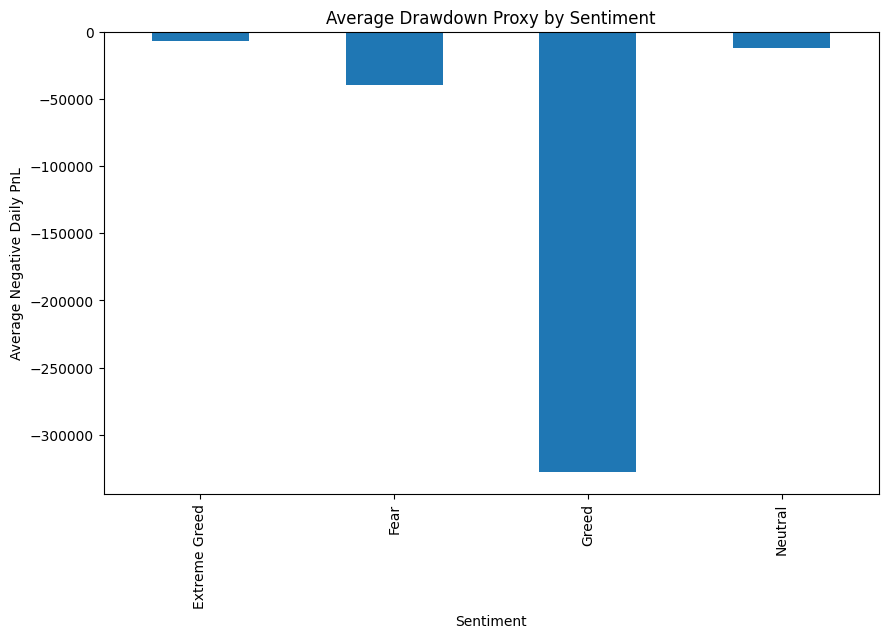

In [11]:
drawdown_analysis.plot(kind='bar')

plt.title('Average Drawdown Proxy by Sentiment')
plt.ylabel('Average Negative Daily PnL')
plt.xlabel('Sentiment')
plt.show()

#**#Question 2**
##Do traders change behavior based on sentiment?

##Trade Frequency

In [12]:
trade_frequency = (
    df.groupby('classification')['Trades_Per_Day']
      .mean()
      .round(2)
)

print(trade_frequency)

classification
Extreme Greed    1392.40
Fear             4183.47
Greed            1134.03
Neutral           892.62
Name: Trades_Per_Day, dtype: float64


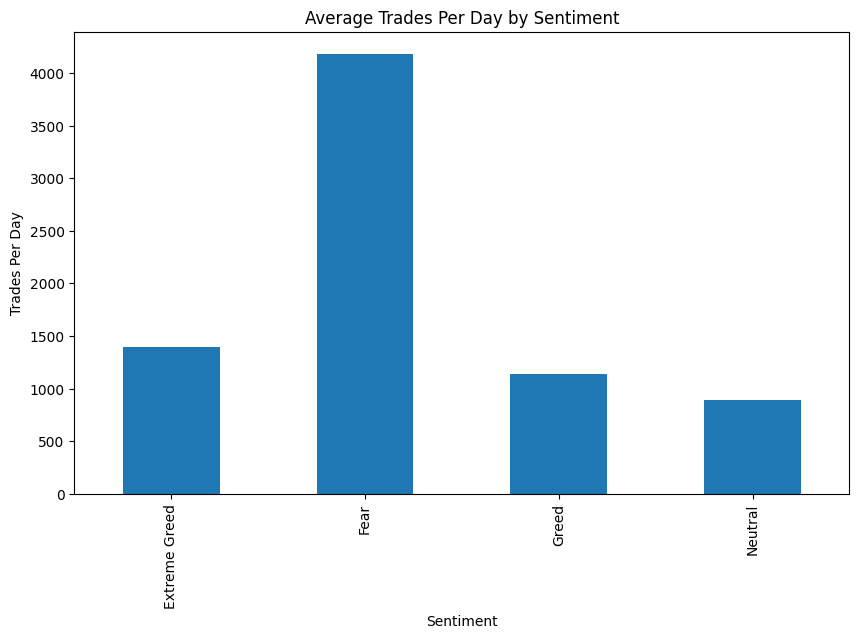

In [13]:
trade_frequency.plot(kind='bar')

plt.title('Average Trades Per Day by Sentiment')
plt.ylabel('Trades Per Day')
plt.xlabel('Sentiment')
plt.show()

##Average Position Size

In [14]:
position_size = (
    df.groupby('classification')['Avg_Trade_Size']
      .mean()
      .round(2)
)

print(position_size)

classification
Extreme Greed    4344.45
Fear             5926.52
Greed            5839.31
Neutral          3793.44
Name: Avg_Trade_Size, dtype: float64


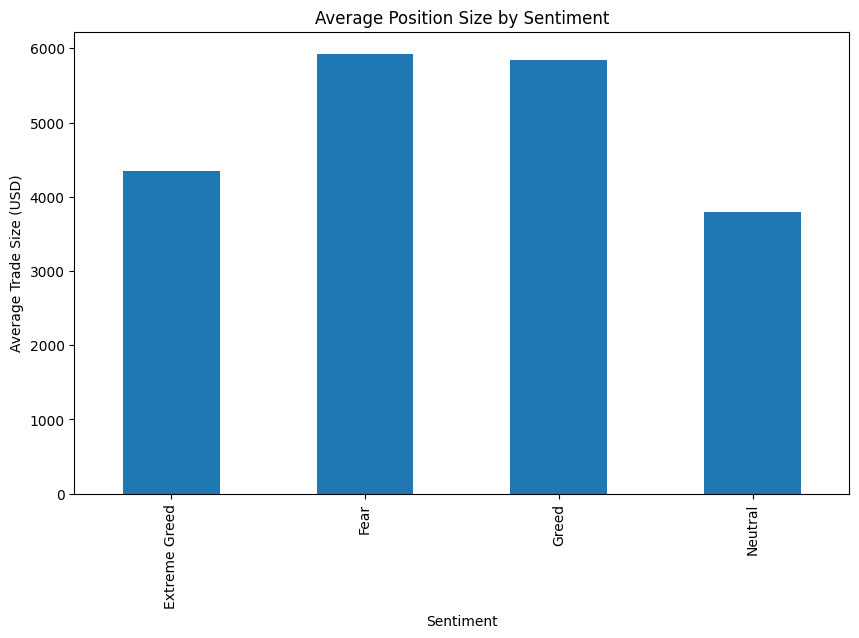

In [15]:
position_size.plot(kind='bar')

plt.title('Average Position Size by Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.xlabel('Sentiment')
plt.show()

##Long / Short Bias

In [16]:
bias_table = pd.crosstab(
    df['classification'],
    df['Trading_Bias']
)

print(bias_table)

Trading_Bias    Balanced  Long_Biased  Only_Long  Only_Short  Short_Biased
classification                                                            
Extreme Greed          0            0          1           0             4
Fear                   0           10          0           1            21
Greed                  0           10          4           2            16
Neutral                1            3          0           0             4


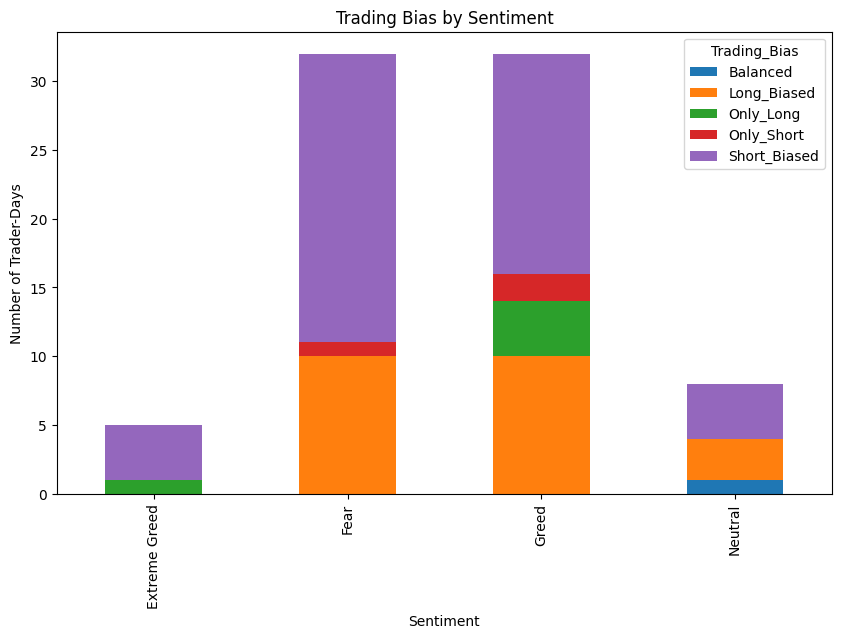

In [17]:
bias_table.plot(
    kind='bar',
    stacked=True
)

plt.title('Trading Bias by Sentiment')
plt.ylabel('Number of Trader-Days')
plt.xlabel('Sentiment')
plt.show()

#Question 3
##Trader Segmentation





###Frequent vs Infrequent Traders

In [18]:
import numpy as np

account_frequency = (
    df.groupby('Account')['Trades_Per_Day']
      .sum()
)

median_frequency = account_frequency.median()

frequent_accounts = account_frequency[
    account_frequency >= median_frequency
].index

df['Frequency_Segment'] = np.where(
    df['Account'].isin(frequent_accounts),
    'Frequent',
    'Infrequent'
)

In [19]:
frequency_results = (
    df.groupby('Frequency_Segment')
      .agg({
          'Daily_PnL':'mean',
          'Win_Rate':'mean',
          'Trades_Per_Day':'mean'
      })
      .round(2)
)

print(frequency_results)

                   Daily_PnL  Win_Rate  Trades_Per_Day
Frequency_Segment                                     
Frequent           204669.19     40.37         4324.58
Infrequent          62764.62     35.14          511.00


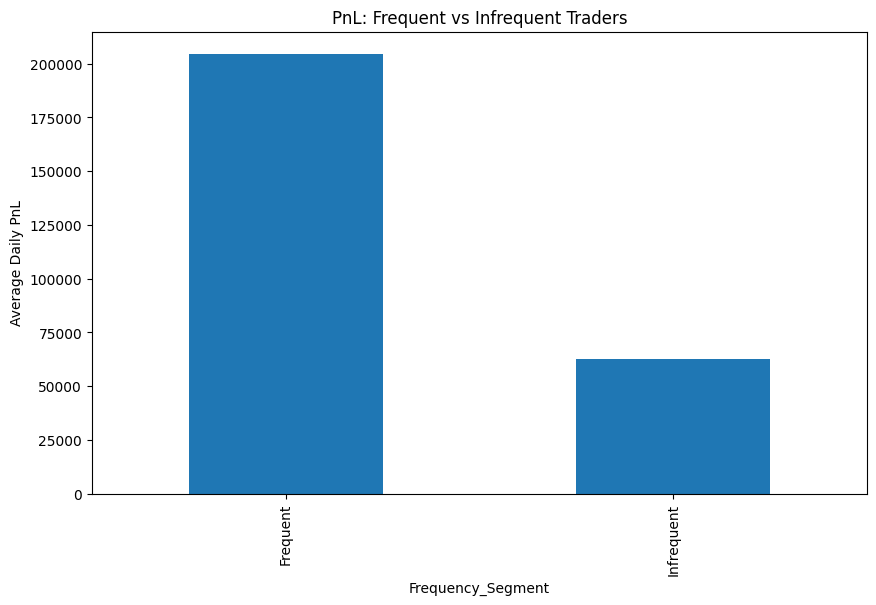

In [20]:
frequency_results['Daily_PnL'].plot(kind='bar')

plt.title('PnL: Frequent vs Infrequent Traders')
plt.ylabel('Average Daily PnL')
plt.show()

###High Risk vs Low Risk Traders

In [21]:
risk_by_account = (
    df.groupby('Account')['Avg_Trade_Size']
      .mean()
)

median_size = risk_by_account.median()

high_risk_accounts = risk_by_account[
    risk_by_account >= median_size
].index

df['Risk_Segment'] = np.where(
    df['Account'].isin(high_risk_accounts),
    'High Risk',
    'Low Risk'
)

In [22]:
risk_results = (
    df.groupby('Risk_Segment')
      .agg({
          'Daily_PnL':'mean',
          'Win_Rate':'mean',
          'Avg_Trade_Size':'mean'
      })
      .round(2)
)

print(risk_results)

              Daily_PnL  Win_Rate  Avg_Trade_Size
Risk_Segment                                     
High Risk     154458.56     31.86         8723.68
Low Risk      109375.87     44.06         2152.15


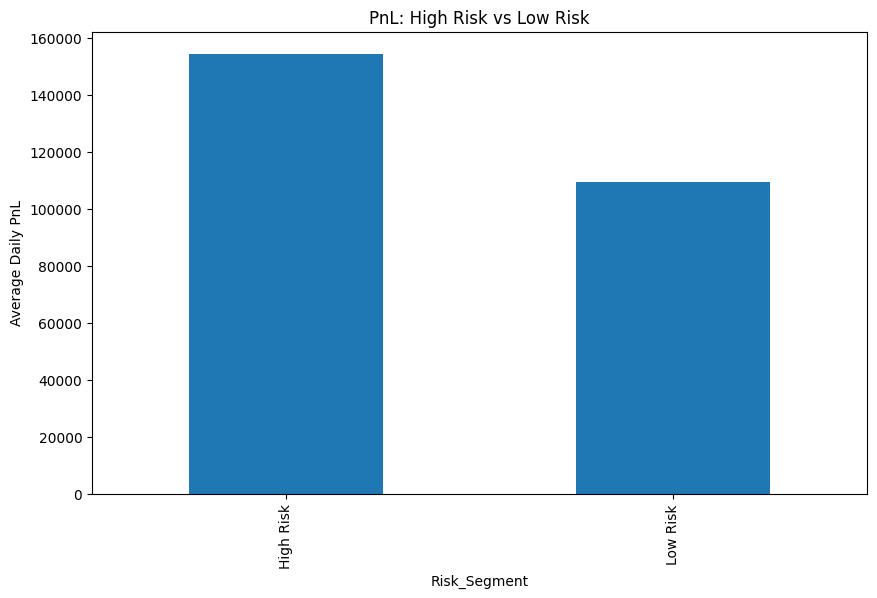

In [23]:
risk_results['Daily_PnL'].plot(kind='bar')

plt.title('PnL: High Risk vs Low Risk')
plt.ylabel('Average Daily PnL')
plt.show()

###Consistent Winners vs Inconsistent Traders

In [24]:
account_winrate = (
    df.groupby('Account')['Win_Rate']
      .mean()
)

winner_accounts = account_winrate[
    account_winrate >= 50
].index

df['Winner_Segment'] = np.where(
    df['Account'].isin(winner_accounts),
    'Consistent Winner',
    'Inconsistent'
)

In [25]:
winner_results = (
    df.groupby('Winner_Segment')
      .agg({
          'Daily_PnL':'mean',
          'Win_Rate':'mean'
      })
      .round(2)
)

print(winner_results)

                   Daily_PnL  Win_Rate
Winner_Segment                        
Consistent Winner   87938.76     60.05
Inconsistent       141076.68     33.60


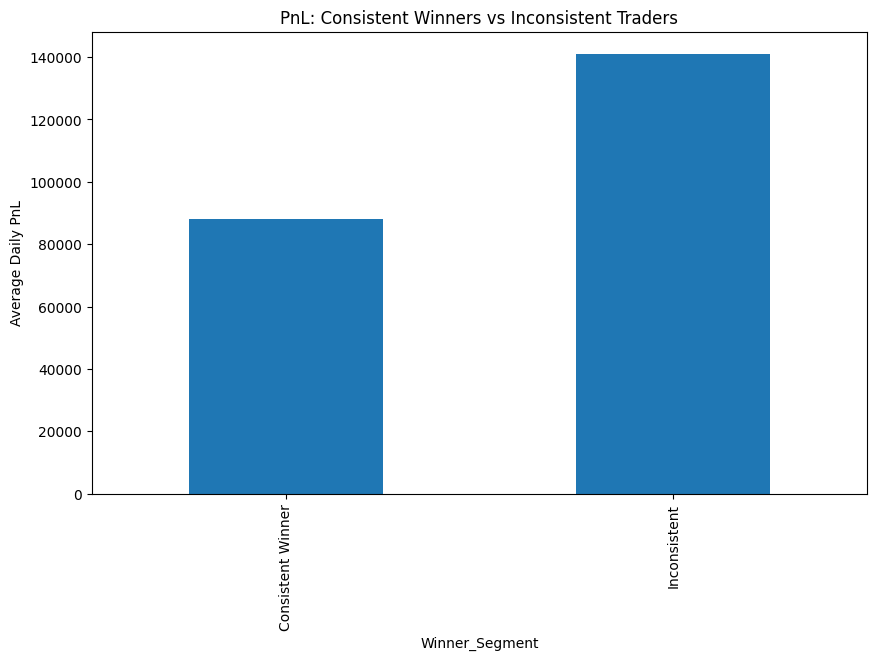

In [26]:
winner_results['Daily_PnL'].plot(kind='bar')

plt.title('PnL: Consistent Winners vs Inconsistent Traders')
plt.ylabel('Average Daily PnL')
plt.show()

#Trader Archetype Clustering

In [27]:
cluster_features = df.groupby('Account').agg({
    'Daily_PnL':'mean',
    'Win_Rate':'mean',
    'Avg_Trade_Size':'mean',
    'Trades_Per_Day':'mean'
})

Training Accuracy : 100.0 %
Testing Accuracy  : 87.5 %


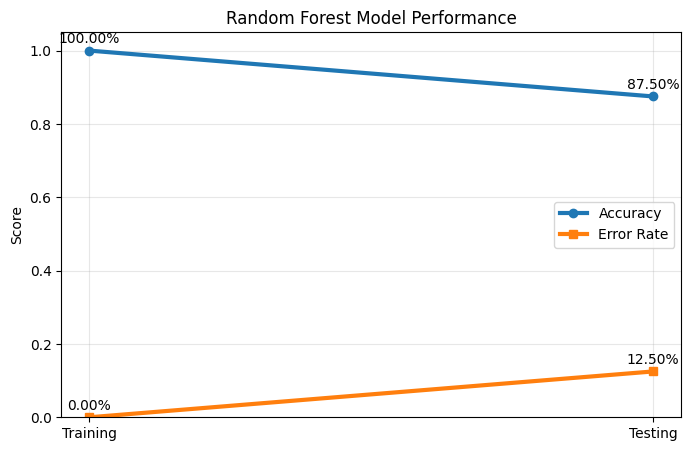


Feature Importance
                  Feature  Importance
2                Win_Rate    0.519869
1          Trades_Per_Day    0.243227
0          Avg_Trade_Size    0.140518
3  Long_Short_Ratio_Fixed    0.096386


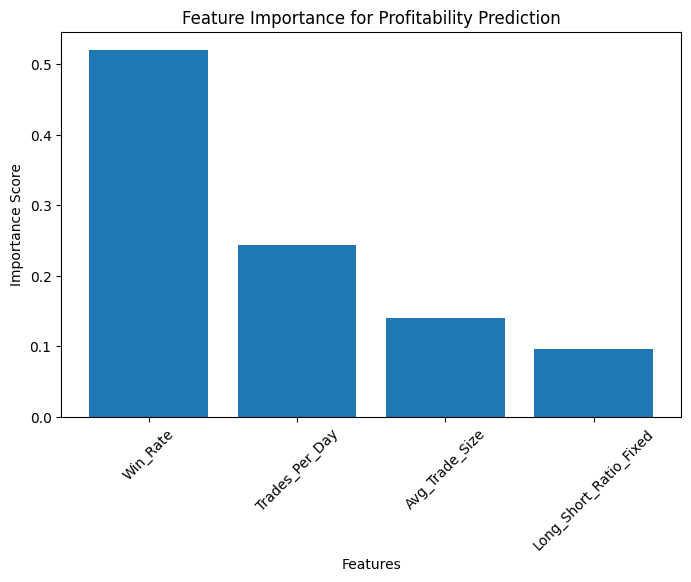

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Prepare Features and Target
# -----------------------------

X = df[
    [
        'Avg_Trade_Size',
        'Trades_Per_Day',
        'Win_Rate',
        'Long_Short_Ratio_Fixed'
    ]
]

y = (df['Daily_PnL'] > 0).astype(int)

# -----------------------------
# Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -----------------------------
# Train Random Forest Model
# -----------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Accuracy Scores
# -----------------------------

train_acc = accuracy_score(
    y_train,
    model.predict(X_train)
)

test_acc = accuracy_score(
    y_test,
    model.predict(X_test)
)

train_error = 1 - train_acc
test_error = 1 - test_acc

print("Training Accuracy :", round(train_acc * 100,2), "%")
print("Testing Accuracy  :", round(test_acc * 100,2), "%")

# -----------------------------
# Double Line Chart
# -----------------------------

plt.figure(figsize=(8,5))

plt.plot(
    ['Training','Testing'],
    [train_acc,test_acc],
    marker='o',
    linewidth=3,
    label='Accuracy'
)

plt.plot(
    ['Training','Testing'],
    [train_error,test_error],
    marker='s',
    linewidth=3,
    label='Error Rate'
)

plt.title('Random Forest Model Performance')
plt.ylabel('Score')
plt.ylim(0,1.05)

plt.grid(True, alpha=0.3)
plt.legend()

for i,v in enumerate([train_acc,test_acc]):
    plt.text(
        i,
        v + 0.02,
        f'{v:.2%}',
        ha='center'
    )

for i,v in enumerate([train_error,test_error]):
    plt.text(
        i,
        v + 0.02,
        f'{v:.2%}',
        ha='center'
    )

plt.show()

# -----------------------------
# Feature Importance Chart
# -----------------------------

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance for Profitability Prediction')
plt.ylabel('Importance Score')
plt.xlabel('Features')

plt.xticks(rotation=45)

plt.show()

In [33]:
cluster_summary = (
    cluster_df
    .groupby('Cluster')
    [
        [
            'Daily_PnL',
            'Win_Rate',
            'Trades_Per_Day',
            'Avg_Trade_Size'
        ]
    ]
    .mean()
    .round(2)
)

print(cluster_summary)

         Daily_PnL  Win_Rate  Trades_Per_Day  Avg_Trade_Size
Cluster                                                     
0        237196.21     36.32         2090.39        15029.33
1         73566.78     37.62         1774.12         3075.45
2        672874.35     47.23        19728.50         2667.42


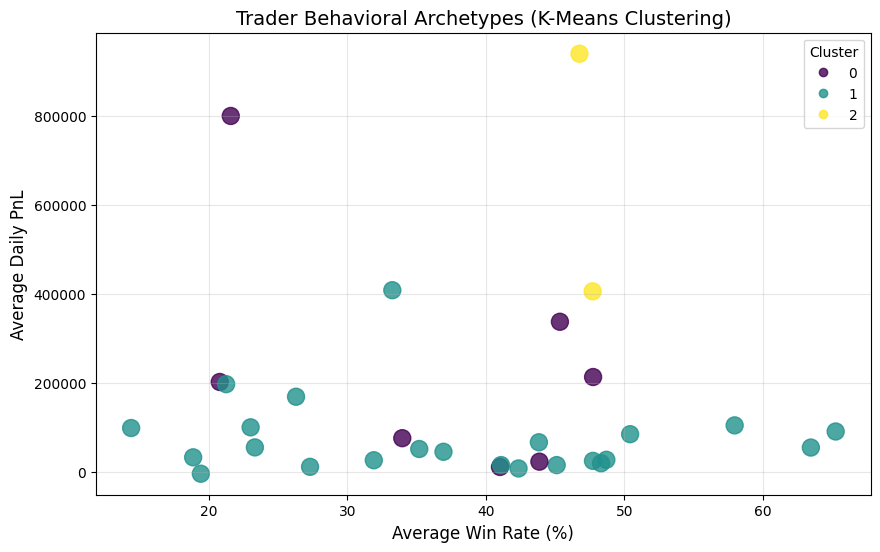

In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Create trader-level features
# -----------------------------------

cluster_df = (
    df.groupby('Account')
    .agg({
        'Daily_PnL':'mean',
        'Win_Rate':'mean',
        'Trades_Per_Day':'mean',
        'Avg_Trade_Size':'mean'
    })
    .reset_index()
)

# -----------------------------------
# Standardize data
# -----------------------------------

features = cluster_df[
    [
        'Daily_PnL',
        'Win_Rate',
        'Trades_Per_Day',
        'Avg_Trade_Size'
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

# -----------------------------------
# K-Means Clustering
# -----------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

# -----------------------------------
# Scatter Plot
# -----------------------------------

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_df['Win_Rate'],
    cluster_df['Daily_PnL'],
    c=cluster_df['Cluster'],
    s=150,
    alpha=0.8
)

plt.title(
    'Trader Behavioral Archetypes (K-Means Clustering)',
    fontsize=14
)

plt.xlabel(
    'Average Win Rate (%)',
    fontsize=12
)

plt.ylabel(
    'Average Daily PnL',
    fontsize=12
)

plt.grid(alpha=0.3)

plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.show()